In [1]:
# Import necessary libraries

import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import pickle # For serializing and deserializing Python objects
from sklearn.metrics import roc_auc_score
import plotly.graph_objects as go

import sys
sys.path.append("/home/suraj/Repositories/TumorImagingBench/notebooks/modelling")

from modelling_utils import (
    train_knn_classifier, evaluate_model,
    train_linear_probing_classifier,
    train_few_shot_classifier,
    build_knn_ensemble_classifier, predict_with_ensemble,
    train_stacking_ensemble_classifier, predict_with_stacking_ensemble,
    plot_model_comparison, extract_model_features, 
    compute_knn_indices, compute_overlap_matrix, plot_overlap_matrix, 
    split_shuffle_data, apply_r_style
)

from pathlib import Path

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATASET_SLUG = 'nsclc_radiomics'
FIG_SIZE = 900


In [2]:
# Load features from a pickle file
feature_dict_path = "/home/suraj/Repositories/TumorImagingBench/data/features/nsclc_radiomics.pkl" # Path to the pickle file containing features
with open(feature_dict_path, 'rb') as file: # Open the file in read binary mode
    data = pickle.load(file) # Load the data from the pickle file




{'train': [{'feature': array([[0.9225959 , 0.7965823 , 0.81736994, 0.8613488 , 0.8707698 ,
           0.7946597 , 0.87448573, 0.76688725, 0.8543553 , 0.8291095 ,
           0.9487843 , 0.83769006, 0.8552427 , 0.89018744, 0.88306487,
           0.8801346 , 0.8571533 , 0.698151  , 0.85961425, 0.60470897,
           0.6915989 , 0.8574889 , 0.819887  , 0.96930695, 0.7744187 ,
           0.703159  , 0.83960193, 0.83447295, 0.8153518 , 0.74975556,
           0.98316944, 0.8732441 , 0.7503158 , 0.88331777, 0.7347733 ,
           1.0441959 , 0.80223453, 0.72058433, 0.84676754, 0.74296993,
           0.8311032 , 0.8269474 , 0.76631355, 0.9606616 , 0.9246497 ,
           0.9340343 , 0.8775078 , 0.9002579 , 0.88449085, 0.8477858 ,
           0.66319656, 0.80569607, 0.9140117 , 0.81765634, 0.9277697 ,
           0.8886685 , 0.83924866, 0.8237839 , 0.9566567 , 0.8046715 ,
           0.8709384 , 0.9029838 , 1.0588744 , 0.7683898 , 0.635124  ,
           0.9126799 , 0.73307645, 0.85551876, 0.75385386

In [3]:
# Store test accuracies for each model
test_accuracies_dict = {}

label_candidates = ["Malignant_lbl", "malignancy", "survival", "label", "target", "status"]

for model_name, values in data.items():
    print(f"Model: {model_name}")
    splits = [s for s in ["train", "val", "test"] if s in values and values[s]]
    if not splits:
        print("  Skipping: no splits found")
        continue

    sample_row = values[splits[0]][0]["row"]
    label_key = next((k for k in label_candidates if k in sample_row), list(sample_row.keys())[0])

    labels = []
    features = []
    for split in splits:
        labels.extend([v["row"][label_key] for v in values[split]])
        features.append(np.vstack([v["feature"] for v in values[split]]))

    labels_arr = np.array(labels)
    if labels_arr.dtype.kind in {"f", "c"}:
        mask = ~np.isnan(labels_arr)
    else:
        mask = np.ones_like(labels_arr, dtype=bool)

    all_items = np.vstack(features)[mask]
    all_labels = labels_arr[mask].tolist()

    n_splits = 10
    split_scores = []

    for split_idx in range(n_splits):
        train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
            all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split_idx, stratify=True
        )

        best_model, study = train_knn_classifier(train_items_s, train_labels_s, val_items_s, val_labels_s)
        split_score = evaluate_model(best_model, test_items_s, test_labels_s)
        split_scores.append(split_score)

    avg_score = np.mean(split_scores)
    std_error = np.std(split_scores, ddof=1) / np.sqrt(n_splits)
    margin = 1.96 * std_error
    ci_lower = avg_score - margin
    ci_upper = avg_score + margin

    test_accuracies_dict[model_name] = {"mean": avg_score, "ci95": (ci_lower, ci_upper)}
    print(f"  AUC: {avg_score:.4f} ± {margin:.4f}")

print("\n✓ KNN probing complete")


[I 2025-12-08 19:22:59,618] A new study created in memory with name: no-name-120ec1b6-dc07-4fd5-a70d-53953873bcec


[I 2025-12-08 19:22:59,633] Trial 0 finished with value: 0.5366205305651673 and parameters: {'k': 29}. Best is trial 0 with value: 0.5366205305651673.


[I 2025-12-08 19:22:59,655] Trial 1 finished with value: 0.4850057670126875 and parameters: {'k': 12}. Best is trial 0 with value: 0.5366205305651673.


[I 2025-12-08 19:22:59,724] Trial 2 finished with value: 0.49596309111880055 and parameters: {'k': 11}. Best is trial 0 with value: 0.5366205305651673.


[I 2025-12-08 19:22:59,754] Trial 3 finished with value: 0.5544982698961938 and parameters: {'k': 42}. Best is trial 3 with value: 0.5544982698961938.


...

[I 2025-12-08 19:23:56,880] Trial 46 finished with value: 0.5470011534025374 and parameters: {'k': 4}. Best is trial 2 with value: 0.6144752018454441.


[I 2025-12-08 19:23:56,893] Trial 47 finished with value: 0.5490196078431373 and parameters: {'k': 1}. Best is trial 2 with value: 0.6144752018454441.


[I 2025-12-08 19:23:56,908] Trial 48 finished with value: 0.4953863898500577 and parameters: {'k': 48}. Best is trial 2 with value: 0.6144752018454441.


[I 2025-12-08 19:23:56,921] Trial 49 finished with value: 0.45732410611303353 and parameters: {'k': 45}. Best is trial 2 with value: 0.6144752018454441.


  AUC: 0.5244 ± 0.0333

✓ KNN probing complete


In [4]:
# Plot test accuracies
fig = plot_model_comparison(test_accuracies_dict, font_size=32, height=FIG_SIZE, width=1400, marker_color="#FCA308")
fig.write_image(PLOTS_DIR / f"nsclc_radiomics_auc.png")

fig.show()


In [5]:
# Intermediate save removed to prevent syntax errors


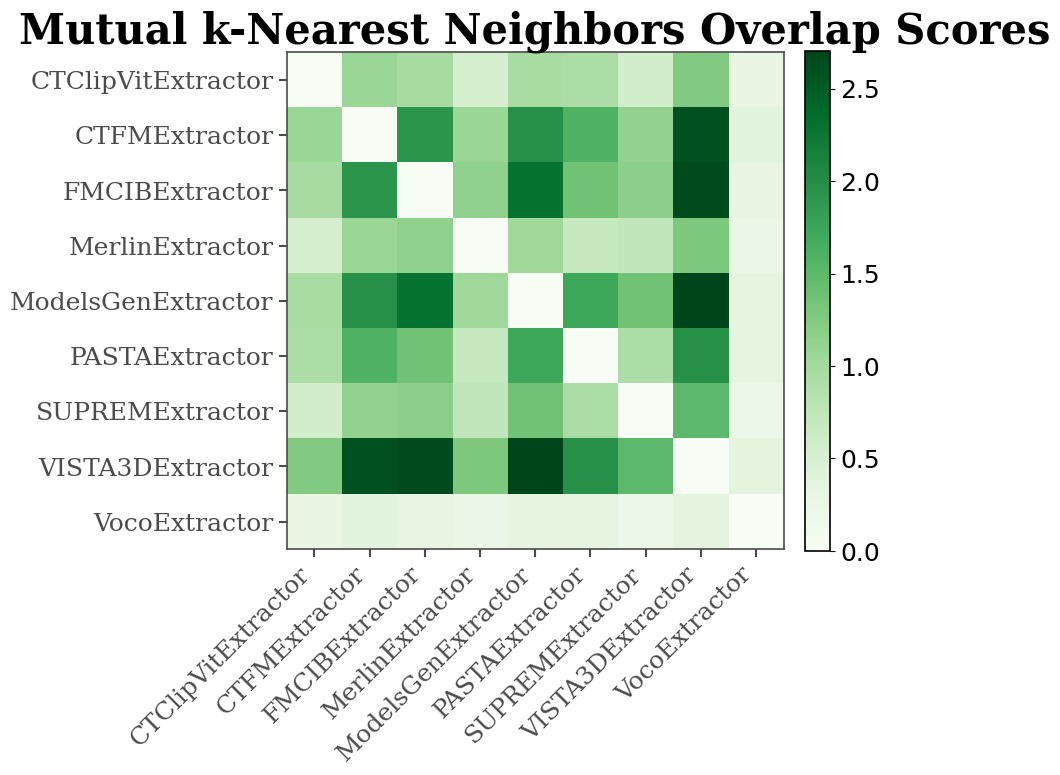

In [6]:
import matplotlib.pyplot as plt

model_features = extract_model_features(data)
model_neighbors = compute_knn_indices(model_features, num_neighbors=10, metric="cosine")
overlap_matrix, model_list = compute_overlap_matrix(model_neighbors)
fig = plot_overlap_matrix(overlap_matrix, model_list, font_size=30, tickangle=45, width=FIG_SIZE, height=FIG_SIZE)
fig.savefig(PLOTS_DIR / f"{DATASET_SLUG}_knn_overlap.png")

plt.show(block=False)

plt.close(fig)

## Linear Probing Evaluation

Evaluate foundation model features using linear probing (logistic regression).
This complements KNN probing and is the standard transfer learning baseline.

In [7]:
# Linear Probing - Train logistic regression on frozen features
linear_probing_results = {}

label_candidates = ["Malignancy", "Malignant_lbl", "malignancy", "survival", "label", "target", "status"]

for model_name, values in data.items():
    print(f"Linear Probing - {model_name}...")
    splits = [s for s in ["train", "val", "test"] if s in values and values[s]]
    if not splits:
        print("  Skipping: no splits found")
        continue

    sample_row = values[splits[0]][0]["row"]
    label_key = next((k for k in label_candidates if k in sample_row), list(sample_row.keys())[0])

    labels = []
    features = []
    for split in splits:
        labels.extend([v["row"][label_key] for v in values[split]])
        features.append(np.vstack([v["feature"] for v in values[split]]))

    labels_arr = np.array(labels)
    if labels_arr.dtype.kind in {"f", "c"}:
        mask = ~np.isnan(labels_arr)
    else:
        mask = np.ones_like(labels_arr, dtype=bool)

    all_items = np.vstack(features)[mask]
    all_labels = labels_arr[mask].tolist()

    n_splits = 10
    linear_split_scores = []

    for split in range(n_splits):
        train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
            all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split, stratify=True
        )

        linear_model, _ = train_linear_probing_classifier(train_items_s, train_labels_s, val_items_s, val_labels_s)
        linear_score = evaluate_model(linear_model, test_items_s, test_labels_s)
        linear_split_scores.append(linear_score)

    avg_score = np.mean(linear_split_scores)
    std_error = np.std(linear_split_scores, ddof=1) / np.sqrt(n_splits)
    margin = 1.96 * std_error
    ci_lower = avg_score - margin
    ci_upper = avg_score + margin

    linear_probing_results[model_name] = {"mean": avg_score, "ci95": (ci_lower, ci_upper)}
    print(f"  Linear Probing AUC: {avg_score:.4f} ± {margin:.4f}")

print("\n✓ Linear probing evaluation complete")


Linear Probing - CTClipVitExtractor...
  Linear Probing AUC: 0.4996 ± 0.0326
Linear Probing - CTFMExtractor...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problem

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



...

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



  Linear Probing AUC: 0.5068 ± 0.0278

✓ Linear probing evaluation complete


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1254: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.



In [8]:
linear_probing_results

{'CTClipVitExtractor': {'mean': 0.499561403508772,
  'ci95': (0.46696065690577143, 0.5321621501117726)},
 'CTFMExtractor': {'mean': 0.5303405572755419,
  'ci95': (0.5021210801793713, 0.5585600343717124)},
 'FMCIBExtractor': {'mean': 0.5468782249742002,
  'ci95': (0.5289777961507146, 0.5647786537976859)},
 'MerlinExtractor': {'mean': 0.605985552115583,
  'ci95': (0.5687772234022742, 0.6431938808288918)},
 'ModelsGenExtractor': {'mean': 0.5578173374613004,
  'ci95': (0.5294485157967582, 0.5861861591258425)},
 'PASTAExtractor': {'mean': 0.5722136222910217,
  'ci95': (0.5477536245702557, 0.5966736200117877)},
 'SUPREMExtractor': {'mean': 0.6048503611971106,
  'ci95': (0.56940001220655, 0.6403007101876711)},
 'VISTA3DExtractor': {'mean': 0.5646542827657378,
  'ci95': (0.541663821899224, 0.5876447436322516)},
 'VocoExtractor': {'mean': 0.5067595459236326,
  'ci95': (0.4789208407464416, 0.5345982511008236)}}

## Few-Shot Learning Evaluation

Evaluate foundation model generalization with limited training data (1-shot, 5-shot, 10-shot).
This assesses how well models work in clinical settings with limited labels.

In [9]:
# Few-Shot Learning - Evaluate with limited training samples
shot_configs = [1, 5, 10]
few_shot_results = {shots: {} for shots in shot_configs}

label_candidates = ["Malignant_lbl", "malignancy", "survival", "label", "target", "status"]

for model_name, values in data.items():
    print(f"Few-Shot Learning - {model_name}...")
    splits = [s for s in ["train", "val", "test"] if s in values and values[s]]
    if not splits:
        print("  Skipping: no splits found")
        continue

    sample_row = values[splits[0]][0]["row"]
    label_key = next((k for k in label_candidates if k in sample_row), list(sample_row.keys())[0])

    labels = []
    features = []
    for split in splits:
        labels.extend([v["row"][label_key] for v in values[split]])
        features.append(np.vstack([v["feature"] for v in values[split]]))

    labels_arr = np.array(labels)
    if labels_arr.dtype.kind in {"f", "c"}:
        mask = ~np.isnan(labels_arr)
    else:
        mask = np.ones_like(labels_arr, dtype=bool)

    all_items = np.vstack(features)[mask]
    all_labels = labels_arr[mask].tolist()

    for shots in shot_configs:
        n_splits = 10
        shot_scores = []

        for split in range(n_splits):
            train_items_s, train_labels_s, val_items_s, val_labels_s, test_items_s, test_labels_s = split_shuffle_data(
                all_items, all_labels, train_ratio=0.5, val_ratio=0.2, random_seed=10+split, stratify=True
            )

            np.random.seed(split)
            few_shot_model, _, _ = train_few_shot_classifier(
                train_items_s, train_labels_s,
                val_items_s, val_labels_s,
                shots=shots
            )

            test_score = evaluate_model(few_shot_model, test_items_s, test_labels_s)
            shot_scores.append(test_score)

        mean_score = np.mean(shot_scores)
        std_error = np.std(shot_scores, ddof=1) / np.sqrt(n_splits)
        margin = 1.96 * std_error

        few_shot_results[shots][model_name] = {"mean": mean_score, "ci95": (mean_score - margin, mean_score + margin)}

        if shots == 1:
            print(f"  {shots}-shot AUC: {mean_score:.4f} ± {margin:.4f} ... 10-shot: ", end="")
        elif shots == 10:
            print(f"{few_shot_results[shots][model_name]['mean']:.4f}")

print("\n✓ Few-shot learning evaluation complete")


[I 2025-12-08 19:24:39,999] A new study created in memory with name: no-name-479e37ef-39af-40cd-8e33-35898fa09e48


[I 2025-12-08 19:24:40,010] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.


[I 2025-12-08 19:24:40,018] Trial 1 finished with value: 0.5049019607843137 and parameters: {'k': 1}. Best is trial 1 with value: 0.5049019607843137.


[I 2025-12-08 19:24:40,029] A new study created in memory with name: no-name-3dbee227-ec4d-4789-802a-0aa1fdbe2601


[I 2025-12-08 19:24:40,040] Trial 0 finished with value: 0.5 and parameters: {'k': 2}. Best is trial 0 with value: 0.5.


...

[I 2025-12-08 19:24:58,241] Trial 16 finished with value: 0.606401384083045 and parameters: {'k': 4}. Best is trial 10 with value: 0.6147635524798155.


[I 2025-12-08 19:24:58,245] Trial 17 finished with value: 0.5833333333333334 and parameters: {'k': 1}. Best is trial 10 with value: 0.6147635524798155.


[I 2025-12-08 19:24:58,250] Trial 18 finished with value: 0.5049019607843137 and parameters: {'k': 16}. Best is trial 10 with value: 0.6147635524798155.


[I 2025-12-08 19:24:58,254] Trial 19 finished with value: 0.35034602076124566 and parameters: {'k': 13}. Best is trial 10 with value: 0.6147635524798155.


0.4977

✓ Few-shot learning evaluation complete


## Few-Shot Learning Curves

Visualize how model performance scales with increasing training samples.

In [10]:
# Plot few-shot learning curves

model_names = list(next(iter(few_shot_results.values())).keys())
fig = go.Figure()

for model_name in model_names:
    shot_values = []
    means = []
    cis = []

    for shots in shot_configs:
        shot_values.append(shots)
        result = few_shot_results.get(shots, {}).get(model_name, {})
        if "mean" not in result or "ci95" not in result:
            continue
        means.append(result["mean"])
        lower, upper = result["ci95"]
        cis.append(upper - result["mean"])

    fig.add_trace(go.Scatter(
        x=shot_values,
        y=means,
        mode='lines+markers',
        name=model_name,
        error_y=dict(type='data', array=cis, visible=True)
    ))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Few-Shot Learning Curves',
    xaxis_title='Number of shots',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white'
)
fig.update_yaxes(range=[0, 1.0])
fig.write_image(PLOTS_DIR / f"nsclc_radiomics_few_shot.png")

fig.show()


## Comparison: KNN vs Linear Probing vs Few-Shot

In [11]:
# Create comparison visualization
model_names = list(linear_probing_results.keys())

knn_means = [test_accuracies_dict[m]['mean'] for m in model_names]
linear_means = [linear_probing_results[m]['mean'] for m in model_names]
few_shot_10_means = [few_shot_results[10][m]['mean'] for m in model_names]

knn_errors = [test_accuracies_dict[m]['ci95'][1] - test_accuracies_dict[m]['mean'] for m in model_names]
linear_errors = [linear_probing_results[m]['ci95'][1] - linear_probing_results[m]['mean'] for m in model_names]
few_shot_errors = [few_shot_results[10][m]['ci95'][1] - few_shot_results[10][m]['mean'] for m in model_names]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=model_names,
    y=knn_means,
    error_y=dict(type='data', array=knn_errors),
    name='KNN Probing',
    marker_color='#4ECDC4'
))

fig.add_trace(go.Bar(
    x=model_names,
    y=linear_means,
    error_y=dict(type='data', array=linear_errors),
    name='Linear Probing',
    marker_color='#FF6B6B'
))

fig.add_trace(go.Bar(
    x=model_names,
    y=few_shot_10_means,
    error_y=dict(type='data', array=few_shot_errors),
    name='10-Shot Learning',
    marker_color='#95E1D3'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Evaluation Protocol Comparison',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    barmode='group',
    height=FIG_SIZE,
    width=1400,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, 1.0])

fig.write_image(PLOTS_DIR / f"nsclc_radiomics_evaluation_protocols.png")

fig.show()

print(f"Correlation KNN vs Linear Probing: {np.corrcoef(knn_means, linear_means)[0, 1]:.4f}")
print(f"Correlation KNN vs 10-Shot: {np.corrcoef(knn_means, few_shot_10_means)[0, 1]:.4f}")
print("Interpretation:")
print("  High KNN-Linear correlation (>0.8): Consistent feature quality assessment")
print("  10-Shot vs KNN: Difference shows data-efficiency gains with simple learning")


Correlation KNN vs Linear Probing: 0.6934
Correlation KNN vs 10-Shot: 0.7590
Interpretation:
  High KNN-Linear correlation (>0.8): Consistent feature quality assessment
  10-Shot vs KNN: Difference shows data-efficiency gains with simple learning


## Alignment-Based Ensemble Method

Combine all models using mutual k-NN overlap alignment as weights.
Models with high alignment with others are weighted more heavily.


In [12]:
# Build alignment-based ensemble
print("Building alignment-based ensemble...\n")

# Extract all features for ensemble
ensemble_features_dict = {}
for model_name, values in data.items():
    features_list = []
    for split in ['train', 'val', 'test']:
        if split in values and values[split]:
            split_features = np.vstack([v['feature'] for v in values[split]])
            features_list.append(split_features)
    ensemble_features_dict[model_name] = np.vstack(features_list) if features_list else np.array([])

# Compute alignment (already computed earlier, but re-using for clarity)
all_labels_ensemble = []
first_model = list(data.keys())[0]
for split in ['train', 'val', 'test']:
    split_labels = [v['row']['survival'] for v in data[first_model][split]]
    all_labels_ensemble.extend(split_labels)

# Evaluate ensemble across multiple splits
n_splits = 10
ensemble_scores = []
individual_ensemble_scores = {m: [] for m in model_list}

for split_idx in range(n_splits):
    # Split data
    (train_idx, train_labels_s, val_idx, val_labels_s, 
     test_idx, test_labels_s) = split_shuffle_data(
        np.arange(len(all_labels_ensemble)), all_labels_ensemble,
        train_ratio=0.5, val_ratio=0.2, random_seed=10+split_idx, stratify=True
    )
    
    # Get features for each split
    train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
    val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}
    test_features_dict = {m: ensemble_features_dict[m][test_idx] for m in model_list}
    
    # Build ensemble
    ensemble_model, ensemble_val = build_knn_ensemble_classifier(
        train_features_dict, train_labels_s,
        val_features_dict, val_labels_s,
        overlap_matrix.copy(), model_list, k=10
    )
    
    # Evaluate ensemble on test
    ensemble_test_preds = predict_with_ensemble(ensemble_model, test_features_dict, model_list)
    
    if ensemble_test_preds.shape[1] == 2:
        ensemble_auc = roc_auc_score(test_labels_s, ensemble_test_preds[:, 1])
    else:
        ensemble_auc = roc_auc_score(test_labels_s, ensemble_test_preds, multi_class='ovr')
    
    ensemble_scores.append(ensemble_auc)
    
    # Evaluate individual models
    from sklearn.neighbors import KNeighborsClassifier
    for model_name in model_list:
        knn = KNeighborsClassifier(n_neighbors=10, metric='cosine')
        knn.fit(train_features_dict[model_name], train_labels_s)
        test_preds = knn.predict_proba(test_features_dict[model_name])
        
        if test_preds.shape[1] == 2:
            model_auc = roc_auc_score(test_labels_s, test_preds[:, 1])
        else:
            model_auc = roc_auc_score(test_labels_s, test_preds, multi_class='ovr')
        
        individual_ensemble_scores[model_name].append(model_auc)
    
    if (split_idx + 1) % 5 == 0:
        print(f"  Completed {split_idx + 1}/{n_splits} splits")

# Compute ensemble statistics
ensemble_mean = np.mean(ensemble_scores)
ensemble_std = np.std(ensemble_scores, ddof=1) / np.sqrt(n_splits)
ensemble_ci = 1.96 * ensemble_std

print(f"\n✓ Ensemble evaluation complete")
print(f"\nEnsemble Performance:")
print(f"  Test AUC: {ensemble_mean:.4f} ± {ensemble_ci:.4f}")

# Compare to individual models
print(f"\nComparison to Individual Models:")
best_model_name = None
best_model_score = 0
for model_name in model_list:
    ind_mean = np.mean(individual_ensemble_scores[model_name])
    ind_std = np.std(individual_ensemble_scores[model_name], ddof=1) / np.sqrt(n_splits)
    ind_ci = 1.96 * ind_std
    improvement = ensemble_mean - ind_mean
    
    if ind_mean > best_model_score:
        best_model_score = ind_mean
        best_model_name = model_name
    
    print(f"  {model_name}: {ind_mean:.4f} ± {ind_ci:.4f}  (ensemble: {improvement:+.4f})")

print(f"\nBest Single Model: {best_model_name} ({best_model_score:.4f})")
print(f"Ensemble Advantage: {ensemble_mean - best_model_score:+.4f}")


Building alignment-based ensemble...



  Completed 5/10 splits


  Completed 10/10 splits

✓ Ensemble evaluation complete

Ensemble Performance:
  Test AUC: 0.6025 ± 0.0228

Comparison to Individual Models:
  CTClipVitExtractor: 0.4594 ± 0.0227  (ensemble: +0.1431)
  CTFMExtractor: 0.5459 ± 0.0230  (ensemble: +0.0565)
  FMCIBExtractor: 0.5730 ± 0.0318  (ensemble: +0.0295)
  MerlinExtractor: 0.5902 ± 0.0345  (ensemble: +0.0123)
  ModelsGenExtractor: 0.5616 ± 0.0332  (ensemble: +0.0409)
  PASTAExtractor: 0.5652 ± 0.0237  (ensemble: +0.0373)
  SUPREMExtractor: 0.5359 ± 0.0235  (ensemble: +0.0666)
  VISTA3DExtractor: 0.5963 ± 0.0247  (ensemble: +0.0062)
  VocoExtractor: 0.5278 ± 0.0336  (ensemble: +0.0747)

Best Single Model: VISTA3DExtractor (0.5963)
Ensemble Advantage: +0.0062


## Ensemble Model Weights

Visualize the alignment-based weights assigned to each model.


In [13]:
# Display ensemble weights from the first evaluation
# (Run one more iteration to get final ensemble model)
train_idx, train_labels_s, val_idx, val_labels_s, test_idx, test_labels_s = split_shuffle_data(
    np.arange(len(all_labels_ensemble)), all_labels_ensemble,
    train_ratio=0.5, val_ratio=0.2, random_seed=50, stratify=True
)

train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}

final_ensemble, _ = build_knn_ensemble_classifier(
    train_features_dict, train_labels_s,
    val_features_dict, val_labels_s,
    overlap_matrix.copy(), model_list, k=10
)

# Extract and visualize weights
weights = final_ensemble['weights']
models_for_plot = list(weights.keys())
weight_values = list(weights.values())

fig = go.Figure()
fig.add_trace(go.Bar(
    x=models_for_plot,
    y=weight_values,
    marker_color='#FCA308',
    text=[f'{w:.3f}' for w in weight_values],
    textposition='auto',
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Ensemble Model Weights (Based on k-NN Alignment)',
    xaxis_title='Model',
    yaxis_title='Weight',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, max(weight_values) * 1.15])

fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_alignment_weights.png")

fig.show()

print(f"\nWeight Statistics:")
print(f"  Max weight: {max(weight_values):.4f}")
print(f"  Min weight: {min(weight_values):.4f}")
print(f"  All weights sum to: {sum(weight_values):.4f}")
print(f"\nInterpretation:")
print(f"  Higher weight = better alignment with other models (consensus)")
print(f"  Lower weight = unique/diverse representation (adds complementary info)")



Weight Statistics:
  Max weight: 0.1667
  Min weight: 0.0371
  All weights sum to: 1.0000

Interpretation:
  Higher weight = better alignment with other models (consensus)
  Lower weight = unique/diverse representation (adds complementary info)


## Stacked Ensemble with Learned Weights

Train a logistic-regression meta-learner on top of per-model k-NN probabilities.

In [14]:
# Stacking ensemble with learned weights (meta-learned combination of models)
from sklearn.neighbors import KNeighborsClassifier

print("Evaluating stacking ensemble with learned weights...")

n_splits = 10
stacking_scores = []
stacking_val_scores = []
last_stacking_model = None
stacking_base_scores = {m: [] for m in model_list}

for split_idx in range(n_splits):
    (train_idx, train_labels_s, val_idx, val_labels_s,
     test_idx, test_labels_s) = split_shuffle_data(
        np.arange(len(all_labels_ensemble)), all_labels_ensemble,
        train_ratio=0.5, val_ratio=0.2, random_seed=110 + split_idx, stratify=True
    )

    train_features_dict = {m: ensemble_features_dict[m][train_idx] for m in model_list}
    val_features_dict = {m: ensemble_features_dict[m][val_idx] for m in model_list}
    test_features_dict = {m: ensemble_features_dict[m][test_idx] for m in model_list}

    stacking_model, val_auc = train_stacking_ensemble_classifier(
        train_features_dict, train_labels_s,
        val_features_dict, val_labels_s,
        k_candidates=(5, 10, 15, 25),
        meta_C_candidates=(0.25, 1.0, 4.0),
    )
    last_stacking_model = stacking_model
    stacking_val_scores.append(val_auc)

    test_pred = predict_with_stacking_ensemble(stacking_model, test_features_dict)
    if test_pred.shape[1] == 2:
        test_auc = roc_auc_score(test_labels_s, test_pred[:, 1])
    else:
        test_auc = roc_auc_score(test_labels_s, test_pred, multi_class='ovr')
    stacking_scores.append(test_auc)

    # Track single-model performance using the same k as the chosen base models
    k_for_base = stacking_model['k']
    for model_name in model_list:
        knn = KNeighborsClassifier(n_neighbors=k_for_base, metric="cosine")
        knn.fit(train_features_dict[model_name], train_labels_s)
        base_pred = knn.predict_proba(test_features_dict[model_name])
        if base_pred.shape[1] == 2:
            base_auc = roc_auc_score(test_labels_s, base_pred[:, 1])
        else:
            base_auc = roc_auc_score(test_labels_s, base_pred, multi_class='ovr')
        stacking_base_scores[model_name].append(base_auc)

    if (split_idx + 1) % 5 == 0:
        print(f"  Completed {split_idx + 1}/{n_splits} splits")

stacking_mean = np.mean(stacking_scores)
stacking_ci = 1.96 * np.std(stacking_scores, ddof=1) / np.sqrt(n_splits)
val_mean = np.mean(stacking_val_scores)

print(f"Stacking ensemble test AUC: {stacking_mean:.4f} ± {stacking_ci:.4f}")
print(f"Validation AUC (meta search average): {val_mean:.4f}")

best_single = None
best_single_score = -np.inf
for model_name, scores in stacking_base_scores.items():
    mean_score = np.mean(scores)
    if mean_score > best_single_score:
        best_single_score = mean_score
        best_single = model_name

print(f"Best single model (matched k): {best_single} — {best_single_score:.4f}")
print(f"Ensemble advantage over best single: {stacking_mean - best_single_score:+.4f}")


Evaluating stacking ensemble with learned weights...


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

...

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

  Completed 10/10 splits
Stacking ensemble test AUC: 0.5621 ± 0.0372
Validation AUC (meta search average): 0.7393
Best single model (matched k): VISTA3DExtractor — 0.5817
Ensemble advantage over best single: -0.0196


/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.

/home/suraj/Repositories/TumorImagingBench/.venv/lib/python3.11/site-package

In [15]:
# Visualize meta-learner weights from the last stacking run
if last_stacking_model is None:
    raise RuntimeError("Run the stacking ensemble cell before visualizing weights.")

meta_model = last_stacking_model['meta_model']
model_list = last_stacking_model['model_list']
coef = meta_model.coef_

n_models = len(model_list)
cols_per_model = coef.shape[1] // n_models

weight_rows = []
for idx, name in enumerate(model_list):
    start = idx * cols_per_model
    end = start + cols_per_model
    block = coef[0, start:end]
    weight_rows.append({
        "model": name,
        "meta_weight": float(np.mean(block))
    })

weight_df = pd.DataFrame(weight_rows)
weight_df['normalized'] = np.exp(weight_df['meta_weight']) / np.exp(weight_df['meta_weight']).sum()
weight_df = weight_df.sort_values('normalized', ascending=False)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=weight_df['model'],
    y=weight_df['normalized'],
    marker_color='#4ECDC4',
    text=[f"{w:.3f}" for w in weight_df['normalized']],
    textposition='auto'
))
apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Stacking Ensemble Meta-weights (softmax-normalized coefficients)',
    xaxis_title='Model',
    yaxis_title='Normalized weight',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45,
)
fig.update_yaxes(range=[0, weight_df['normalized'].max() * 1.15])

fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_stacking_weights.png")

fig.show()

print("Raw meta coefficients (per-model mean):")
print(weight_df[['model', 'meta_weight']].to_string(index=False))


Raw meta coefficients (per-model mean):
             model  meta_weight
   MerlinExtractor     2.779076
    PASTAExtractor     1.964523
ModelsGenExtractor     1.242213
    FMCIBExtractor     0.680688
     VocoExtractor     0.383826
  VISTA3DExtractor     0.332110
CTClipVitExtractor    -0.587794
   SUPREMExtractor    -1.665155
     CTFMExtractor    -1.918291


In [16]:
# Compare ensembles against best single model
if 'ensemble_mean' not in globals() or 'stacking_mean' not in globals():
    raise RuntimeError("Run alignment and stacking sections first.")

best_single_name = best_model_name
best_single_mean = best_model_score
best_single_ci = 1.96 * np.std(individual_ensemble_scores[best_single_name], ddof=1) / np.sqrt(len(individual_ensemble_scores[best_single_name]))

labels = [f"Best single ({best_single_name})", "Alignment ensemble", "Stacking ensemble"]
means = [best_single_mean, ensemble_mean, stacking_mean]
errors = [best_single_ci, ensemble_ci, stacking_ci]
colors = ['#4ECDC4', '#FCA308', '#FF6B6B']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=labels,
    y=means,
    error_y=dict(type='data', array=errors),
    marker_color=colors,
    text=[f"{m:.3f}" for m in means],
    textposition='auto'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Alignment vs Stacking vs Best Single',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=20
)
fig.update_yaxes(range=[0, 1.0])
fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_ensemble_comparison.png")

fig.show()

print(f"Stacking uplift over best single: {stacking_mean - best_single_mean:+.4f}")
print(f"Stacking uplift over alignment ensemble: {stacking_mean - ensemble_mean:+.4f}")


Stacking uplift over best single: -0.0342
Stacking uplift over alignment ensemble: -0.0404


In [17]:
# Plot ensemble vs single-model performance
model_names_plot = list(test_accuracies_dict.keys())
ind_means = [test_accuracies_dict[m]['mean'] for m in model_names_plot]
ind_errors = [test_accuracies_dict[m]['ci95'][1] - test_accuracies_dict[m]['mean'] for m in model_names_plot]

ensembles = [(ensemble_mean, ensemble_ci), (stacking_mean, stacking_ci)]

final_ensemble_mean, final_ensemble_ci = max(ensembles, key=lambda x: x[0])

bar_names = model_names_plot + ["Ensemble"]
bar_means = ind_means + [final_ensemble_mean]
bar_errors = ind_errors + [final_ensemble_ci]

colors = ['#4ECDC4'] * len(model_names_plot) + ['#FCA308']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=bar_names,
    y=bar_means,
    error_y=dict(type='data', array=bar_errors),
    marker_color=colors,
    text=[f"{m:.3f}" for m in bar_means],
    textposition='auto'
))

apply_r_style(fig, font_size=32)
fig.update_layout(
    title='Ensemble vs Individual Models',
    xaxis_title='Model',
    yaxis_title='Test AUC',
    height=FIG_SIZE,
    width=FIG_SIZE,
    template='simple_white',
    xaxis_tickangle=45
)
fig.update_yaxes(range=[0, 1.0])

fig.write_image(PLOTS_DIR / f"{DATASET_SLUG}_ensemble_vs_individual.png")

fig.show()

best_ind_mean = max(ind_means) if ind_means else float('nan')
print(f"Ensemble uplift over best single: {ensemble_mean - best_ind_mean:+.4f}")


Ensemble uplift over best single: +0.0198


In [18]:
# Intermediate save removed to prevent syntax errors


In [19]:
# Save all results to CSV
import pandas as pd
from pathlib import Path

def update_results_csv():
    results_map = {
        'KNN': test_accuracies_dict,
        'Linear': linear_probing_results,
        '10Shot': few_shot_results[10]
    }
    
    csv_path = Path('/home/suraj/Repositories/TumorImagingBench/overall_results.csv')
    if csv_path.exists():
        try:
            df = pd.read_csv(csv_path)
            if 'Models' in df.columns:
                df.set_index('Models', inplace=True)
            # Remove Unnamed columns
            df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
            # Drop old columns for this dataset to refresh
            cols_to_drop = [c for c in df.columns if c.startswith(f'{DATASET_SLUG}')]
            df.drop(columns=cols_to_drop, inplace=True)
        except Exception as e:
            print(f'Error reading CSV: {e}')
            df = pd.DataFrame()
    else:
        df = pd.DataFrame()

    # Process per-model results
    for strategy, results in results_map.items():
        for model, metrics in results.items():
            if model not in df.index:
                df.loc[model, :] = pd.NA
            
            prefix = f'{DATASET_SLUG}_{strategy}'
            df.loc[model, prefix] = metrics['mean']
            df.loc[model, f'{prefix}_CI_Lower'] = metrics['ci95'][0]
            df.loc[model, f'{prefix}_CI_Upper'] = metrics['ci95'][1]

    # Process Ensemble
    ens_mean, ens_ci = None, None
    if 'stacking_mean' in globals():
        ens_mean = stacking_mean
        ens_ci = stacking_ci
    elif 'ensemble_mean' in globals():
        ens_mean = ensemble_mean
        ens_ci = ensemble_ci

    if ens_mean is not None:
        ens_model = 'Ensemble'
        if ens_model not in df.index:
            df.loc[ens_model, :] = pd.NA
        
        # Save ensemble result. Use a specific strategy name or repurpose one?
        # Let's use 'Ensemble' as strategy suffix
        prefix = f'{DATASET_SLUG}_Ensemble'
        df.loc[ens_model, prefix] = ens_mean
        df.loc[ens_model, f'{prefix}_CI_Lower'] = ens_mean - ens_ci
        df.loc[ens_model, f'{prefix}_CI_Upper'] = ens_mean + ens_ci

    df.reset_index(names='Models', inplace=True)
    df.to_csv(csv_path, index=False)
    print('Results updated in overall_results.csv')

update_results_csv()


Results updated in overall_results.csv
